# Метод 1 — CatBoost. Часть 2: обучение (default + Optuna)

Здесь реализация двух вариантов CatBoost: с параметрами по умолчанию и с поиском Optuna (25 trials, TPE-семплер). 

Для каждого варианта измеряем кросс-валидационный SMLAR, монотонные нарушения и собираем Split CP-покрытие на внутренней калибрационной подвыборке. 

По ходу Optuna-поиска сохраняем PNG-кадры прогресса (best-so-far CV SMLAR).

In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_1_catboost'
OUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from catboost import CatBoostRegressor
import optuna

from core.ci import ConformalEvaluation, aggregate_cp_coverage, seeded_train_calib_split
from core.config import ALPHA, INNER_CALIB_FRAC, MODEL_DIR, SEED, TARGETS, set_seed
from core.conformal import MultiTargetSplitCP
from core.leak_safe_features import build_leak_safe_aggregates
from core.metrics import monotonicity_violation, monotonicity_violation_per_pair, smlar, smlar_per_target
from core.runner import load_unified_data

set_seed()

In [11]:
data = load_unified_data()
split = data['split']

X = build_leak_safe_aggregates(data['val'], data['user_index'], data['pub_index'])
y = data['ans'][list(TARGETS)].astype(float)

train_idx = split['train_idx']
holdout_idx = split['holdout_idx']
folds = split['folds']

print(f"X: {X.shape}, y: {y.shape}")
print(f"train: {len(train_idx)}, holdout: {len(holdout_idx)}, фолдов: {len(folds)}")

X: (1008, 39), y: (1008, 3)
train: 806, holdout: 202, фолдов: 5


### Запуск (CV + holdout + Split CP)

In [ ]:
def _run_variant(variant_name, cb_params, X, y, train_idx, holdout_idx, folds):
    fold_smlar = []
    fold_smlar_pt = []   # per-target SMLAR на каждом фолде
    fold_mono = []
    fold_mono_pair = []  # per-pair (y1_vs_y2, y2_vs_y3) на каждом фолде
    cp_evals = []
    for fold_i, (tr, va) in enumerate(folds):
        n_tr = len(tr)
        sub_local, cal_local = seeded_train_calib_split(n_tr, INNER_CALIB_FRAC, SEED + fold_i)
        sub_idx = tr[sub_local]
        cal_idx = tr[cal_local]

        model = CatBoostRegressor(**cb_params)
        model.fit(X.iloc[sub_idx].values, y.iloc[sub_idx].values)
        pred_cal = np.clip(model.predict(X.iloc[cal_idx].values), 0.0, 1.0)
        pred_va = np.clip(model.predict(X.iloc[va].values), 0.0, 1.0)

        fold_smlar.append(smlar(y.iloc[va].values, pred_va))
        fold_smlar_pt.append(smlar_per_target(y.iloc[va].values, pred_va))
        fold_mono.append(monotonicity_violation(pred_va))
        fold_mono_pair.append(monotonicity_violation_per_pair(pred_va))

        cp = MultiTargetSplitCP(alpha=ALPHA).calibrate(y.iloc[cal_idx].values, pred_cal)
        lo, hi = cp.predict(pred_va)
        cp_evals.append(ConformalEvaluation(
            y_true=y.iloc[va].values.astype(np.float64),
            y_pred=pred_va.astype(np.float64),
            lower=lo, upper=hi,
            quantiles_per_target=[float(c.quantile_) for c in cp.per_target_],
        ))

    cv_smlar_mean = float(np.mean(fold_smlar))
    cv_smlar_std = float(np.std(fold_smlar, ddof=0))
    cv_mono_mean = float(np.mean(fold_mono))

    # CV per-target: усреднение по фолдам ключ за ключом.
    cv_smlar_pt_mean = {t: float(np.mean([d[t] for d in fold_smlar_pt])) for t in TARGETS}
    cv_smlar_pt_std = {t: float(np.std([d[t] for d in fold_smlar_pt], ddof=0)) for t in TARGETS}
    cv_mono_pair_mean = {
        k: float(np.mean([d[k] for d in fold_mono_pair]))
        for k in ('y1_vs_y2', 'y2_vs_y3')
    }

    full_model = CatBoostRegressor(**cb_params)
    full_model.fit(X.iloc[train_idx].values, y.iloc[train_idx].values)
    pred_ho = np.clip(full_model.predict(X.iloc[holdout_idx].values), 0.0, 1.0)
    ho_smlar = smlar(y.iloc[holdout_idx].values, pred_ho)
    ho_mono = monotonicity_violation(pred_ho)
    ho_per_target = smlar_per_target(y.iloc[holdout_idx].values, pred_ho)
    ho_mono_pair = monotonicity_violation_per_pair(pred_ho)

    cp_agg = aggregate_cp_coverage(cp_evals)

    if variant_name == 'catboost-optuna':
        MODEL_DIR.mkdir(exist_ok=True)
        full_model.save_model(str(MODEL_DIR / 'best_catboost_optuna.cbm'))

    return {
        'name': variant_name,
        'cv_fold_smlar': fold_smlar,
        'cv_fold_smlar_per_target': fold_smlar_pt,
        'cv_fold_mono_pair': fold_mono_pair,
        'cv': {
            'smlar_flat_mean': cv_smlar_mean,
            'smlar_flat_std': cv_smlar_std,
            'smlar_per_target': cv_smlar_pt_mean,
            'smlar_per_target_std': cv_smlar_pt_std,
            'monotone_viol_mean': cv_mono_mean,
            'monotone_viol_per_pair': cv_mono_pair_mean,
        },
        'holdout': {
            'smlar_flat': float(ho_smlar),
            'smlar_per_target': ho_per_target,
            'monotone_viol': float(ho_mono),
            'monotone_viol_per_pair': ho_mono_pair,
        },
        'ci': {
            'type': 'split_cp',
            'alpha': ALPHA,
            'coverage_per_target': cp_agg['coverage_per_target'],
            'width_per_target': cp_agg['width_per_target'],
        },
        'params': cb_params,
    }

### Вариант 1 — CatBoost с параметрами по умолчанию

In [13]:
default_params = {
    'iterations': 800,
    'depth': 6,
    'learning_rate': 0.05,
    'loss_function': 'MultiRMSE',
    'verbose': 0,
    'random_seed': SEED,
    'allow_writing_files': False,
}
t0 = time.time()
default_res = _run_variant('catboost-default', default_params, X, y, train_idx, holdout_idx, folds)
t_default = time.time() - t0
print(f"catboost-default: CV SMLAR {default_res['cv']['smlar_flat_mean']:.2f}% ± {default_res['cv']['smlar_flat_std']:.2f} ({t_default:.1f}s)")
print(f"holdout SMLAR: {default_res['holdout']['smlar_flat']:.2f}%")
print(f"монотонные нарушения (CV): {default_res['cv']['monotone_viol_mean']*100:.2f}%")

catboost-default: CV SMLAR 47.59% ± 5.49 (6.2s)
holdout SMLAR: 40.88%
монотонные нарушения (CV): 4.72%


### Optuna-поиск гиперпараметров (30 trials)

In [14]:
def _objective_factory(X, y, folds):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 200, 1500, step=100),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
            'loss_function': 'MultiRMSE',
            'verbose': 0,
            'random_seed': SEED,
            'allow_writing_files': False,
        }
        scores = []
        for tr, va in folds:
            m = CatBoostRegressor(**params)
            m.fit(X.iloc[tr].values, y.iloc[tr].values)
            scores.append(smlar(y.iloc[va].values, np.clip(m.predict(X.iloc[va].values), 0, 1)))
        return float(np.mean(scores))
    return objective


def search_optuna_params(X, y, folds, n_trials=30, on_trial=None):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    callbacks = [on_trial] if on_trial is not None else None
    study.optimize(_objective_factory(X, y, folds), n_trials=n_trials, callbacks=callbacks)
    return study.best_params, study

In [15]:
N_TRIALS = 30
trial_history = []  # (trial_number, trial_value, best_so_far)

def _save_progress_frame(trial_number, trial_value, best_value):
    trial_history.append((trial_number, trial_value, best_value))
    xs = [t[0] for t in trial_history]
    bests = [t[2] for t in trial_history]
    vals = [t[1] for t in trial_history]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(xs, vals, 'o', color='skyblue', alpha=0.6, label='SMLAR trial')
    ax.plot(xs, bests, '-', color='brown', linewidth=2.2, label='Best-so-far SMLAR')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV SMLAR (%)')
    ax.set_title(f'Optuna прогресс: trial {trial_number}/{N_TRIALS} (best={best_value:.3f}%)')
    ax.set_xlim(0, N_TRIALS + 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'fig_optuna_trial_{trial_number:03d}.png', dpi=110)
    plt.close(fig)


def optuna_callback(study, trial):
    best = study.best_value if study.best_trial is not None else trial.value
    _save_progress_frame(trial.number + 1, float(trial.value), float(best))

In [16]:
t0 = time.time()
best_params, study = search_optuna_params(X, y, folds, n_trials=N_TRIALS, on_trial=optuna_callback)
t_search = time.time() - t0
print(f"Optuna поиск завершён за {t_search:.1f}s")
print(f"Лучшие параметры: {best_params}")
print(f"Сохранено {len(trial_history)} кадров прогресса в {OUT_DIR}")

Optuna поиск завершён за 346.1s
Лучшие параметры: {'iterations': 1500, 'depth': 6, 'learning_rate': 0.02387815877685022, 'l2_leaf_reg': 0.9110885730277368, 'random_strength': 0.18089163939445757}
Сохранено 30 кадров прогресса в /Users/ensamsanovich/auc_forecast/outputs/method_1_catboost


### Вариант 2 — CatBoost с найденными Optuna параметрами

Модель сохраняется `model/best_catboost_optuna.cbm`

In [17]:
optuna_params = {
    **best_params,
    'loss_function': 'MultiRMSE',
    'verbose': 0,
    'random_seed': SEED,
    'allow_writing_files': False,
}
t0 = time.time()
optuna_res = _run_variant('catboost-optuna', optuna_params, X, y, train_idx, holdout_idx, folds)
t_opt = time.time() - t0
print(f"catboost-optuna: CV SMLAR {optuna_res['cv']['smlar_flat_mean']:.2f}% ± {optuna_res['cv']['smlar_flat_std']:.2f} ({t_opt:.1f}s)")
print(f"holdout SMLAR: {optuna_res['holdout']['smlar_flat']:.2f}%")
print(f"монотонные нарушения (CV): {optuna_res['cv']['monotone_viol_mean']*100:.2f}%")

catboost-optuna: CV SMLAR 41.24% ± 4.95 (12.0s)
holdout SMLAR: 33.66%
монотонные нарушения (CV): 6.95%


In [18]:
optuna_params = {
    **best_params,
    'loss_function': 'MultiRMSE',
    'verbose': 0,
    'random_seed': SEED,
    'allow_writing_files': False,
}
t0 = time.time()
optuna_res = _run_variant('catboost-optuna', optuna_params, X, y, train_idx, holdout_idx, folds)
t_opt = time.time() - t0
print(f"catboost-optuna: CV SMLAR {optuna_res['cv']['smlar_flat_mean']:.2f}% ± {optuna_res['cv']['smlar_flat_std']:.2f} ({t_opt:.1f}s)")
print(f"holdout SMLAR: {optuna_res['holdout']['smlar_flat']:.2f}%")
print(f"монотонные нарушения (CV): {optuna_res['cv']['monotone_viol_mean']*100:.2f}%")

catboost-optuna: CV SMLAR 41.24% ± 4.95 (12.1s)
holdout SMLAR: 33.66%
монотонные нарушения (CV): 6.95%


### Сравнение двух вариантов

In [19]:
compare = pd.DataFrame([
    {
        'variant': 'catboost-default',
        'cv_smlar_mean': default_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': default_res['cv']['smlar_flat_std'],
        'holdout_smlar': default_res['holdout']['smlar_flat'],
        'mono_viol_cv': default_res['cv']['monotone_viol_mean'],
    },
    {
        'variant': 'catboost-optuna',
        'cv_smlar_mean': optuna_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': optuna_res['cv']['smlar_flat_std'],
        'holdout_smlar': optuna_res['holdout']['smlar_flat'],
        'mono_viol_cv': optuna_res['cv']['monotone_viol_mean'],
    },
])
compare

,variant,cv_smlar_mean,cv_smlar_std,holdout_smlar,mono_viol_cv
0,catboost-default,47.591145,5.487627,40.88114,0.047151
1,catboost-optuna,41.243052,4.948698,33.66008,0.069512


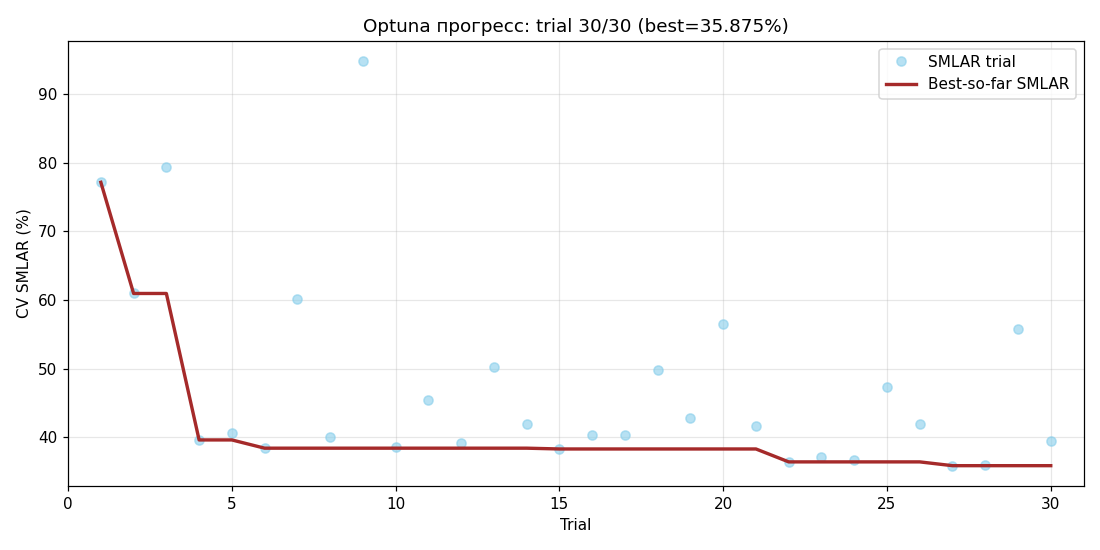

In [20]:
final_frame = OUT_DIR / f'fig_optuna_trial_{N_TRIALS:03d}.png'
if final_frame.exists():
    display(Image(filename=str(final_frame)))
else:
    last = sorted(OUT_DIR.glob('fig_optuna_trial_*.png'))[-1]
    display(Image(filename=str(last)))

### Результаты

- Обучены CatBoost с параметрами по умолчанию и его Optuna вариант.
- Сохранена история прогресса поиска гиперпараметров.
- Лучшая модель сохранена в `model/best_catboost_optuna.cbm` и будет использована в тетради 3.

## CatBoost с SMLAR-smooth функцией потерь

Эксперимент добавлен для сравнения с MLP-smlar_smooth.
Гипотеза: gap между CatBoost-optuna и MLP связан не только с архитектурой,
но и с функцией потерь.

Реализуем кастомный лосс для CatBoost — аналог `core.metrics.smlar_smooth_loss`:

$$L(p, t) = \sqrt{\log\!\left(\frac{p + \varepsilon}{t + \varepsilon}\right)^{\!2} + \alpha^2} \; - \; \alpha$$

с $\varepsilon = 0.005$ (из `core.config.EPS`) и $\alpha = 0.01$ (как у MLP).

**Архитектура.** В CatBoost 1.2.x кастомные multi-target objectives для регрессии
не поддерживаются (поддерживаются только для multi-classification, см.
`catboost/private/libs/target/data_providers.cpp`). Поэтому multi-target вариант
эмулируется тремя независимыми `CatBoostRegressor`-ами — по одной модели на
$y_1, y_2, y_3$ — каждая с 1-мерным `calc_ders_range`. Это совпадает по семантике
с MLP-вариантом, где `smlar_smooth_loss` действует на flattened-предсказания (сумма
посимметрична по всем выходам).

**Производные** для 1-мерного случая:

$$\frac{\partial L}{\partial p} = \frac{r}{\sqrt{r^2 + \alpha^2}} \cdot \frac{1}{p + \varepsilon}, \quad
\frac{\partial^2 L}{\partial p^2} = \frac{1}{(p + \varepsilon)^2}\left(\frac{\alpha^2}{(r^2+\alpha^2)^{3/2}} - \frac{r}{\sqrt{r^2+\alpha^2}}\right)$$

где $r = \log((p+\varepsilon)/(t+\varepsilon))$. Псевдо-Хубер на лог-шкале не строго
выпуклый по $p$ (вторая производная может стать отрицательной при больших $r > 0$),
поэтому Гессиан клипуется снизу к маленькому положительному значению — иначе CatBoost
не сможет посчитать Newton-step для значения листа.

**Протокол.** Те же leak-safe фичи, тот же `SEED=42`, те же 5 фолдов и тот же
holdout. Гиперпараметры дерева — как у `catboost-default` (iterations=800, depth=6,
lr=0.05), чтобы изолировать эффект **только** замены функции потерь.

In [21]:
# Кастомный 1D-objective для CatBoost — аналог core.metrics.smlar_smooth_loss
# (используется в MLP). CatBoost 1.2.x не поддерживает custom multi-target regression
# objectives, поэтому multi-target тренируется тремя независимыми моделями.


from core.config import EPS
ALPHA_SMOOTH = 0.01  # совпадает с дефолтом smlar_smooth_loss(alpha=0.01) у MLP


class SMLARSmoothObjective1D:
    """Пер-объектный custom loss для одиночного CatBoostRegressor.

    Для каждой пары (p, t):
        L = sqrt(log((p + eps)/(t + eps))^2 + alpha^2) - alpha

    Производные:
        r        = log((p + eps) / (t + eps))
        dL/dp    = (r / sqrt(r^2 + a^2)) / (p + eps)
        d^2L/dp^2 = (1/(p+eps)^2) * (a^2 / (r^2+a^2)^{3/2} - r / sqrt(r^2+a^2))

    Конвенция CatBoost (см. примеры RMSE/LogLoss в доке):
        der1 = -dL/dapprox
        der2 = -d^2L/dapprox^2   (должна быть <= -min_pos для валидного Newton-step)
    """

    def __init__(self, eps: float = EPS, alpha: float = ALPHA_SMOOTH, min_hess: float = 1e-6):
        self.eps = float(eps)
        self.alpha = float(alpha)
        self.alpha2 = self.alpha * self.alpha
        self.min_hess = float(min_hess)

    def calc_ders_range(self, approxes, targets, weights):
        eps = self.eps
        alpha2 = self.alpha2
        min_pos = self.min_hess
        result = []
        for i in range(len(targets)):
            p_plus = float(approxes[i]) + eps
            t_plus = float(targets[i]) + eps
            w = 1.0 if weights is None else float(weights[i])
            # Вне области определения log — нулевой градиент, маленький положительный 2-й производный.
            if p_plus <= 1e-8 or t_plus <= 1e-8:
                result.append((0.0, -min_pos * w))
                continue
            log_r = math.log(p_plus / t_plus)
            denom = math.sqrt(log_r * log_r + alpha2)  # >= alpha > 0
            dL_dp = (log_r / denom) / p_plus
            inv_p2 = 1.0 / (p_plus * p_plus)
            d2L_dp2 = inv_p2 * (alpha2 / (denom ** 3) - log_r / denom)
            # Псевдо-Хубер на лог-шкале может дать отрицательный 2-й производный при r > 0.
            # Клипуем до маленького положительного, иначе Newton-step в листе невалиден.
            if d2L_dp2 < min_pos:
                d2L_dp2 = min_pos
            result.append((-dL_dp * w, -d2L_dp2 * w))
        return result


In [ ]:
# Эксперимент добавлен для сравнения с MLP-smlar_smooth.
# Гипотеза: gap между CatBoost-optuna и MLP связан не только с архитектурой,
# но и с функцией потерь.

def _run_smlar_variant(variant_name, cb_params, X, y, train_idx, holdout_idx, folds):
    """Аналог _run_variant, но обучает K=3 независимых CatBoostRegressor — по одной
    модели на каждый таргет, поскольку CatBoost 1.2.x не поддерживает кастомные
    multi-target regression objectives.

    Протокол (фолды, calib-split, Split CP, holdout) полностью совпадает с _run_variant.
    """
    K = y.shape[1]
    fold_smlar, fold_smlar_pt, fold_mono, fold_mono_pair, cp_evals = [], [], [], [], []

    for fold_i, (tr, va) in enumerate(folds):
        n_tr = len(tr)
        sub_local, cal_local = seeded_train_calib_split(n_tr, INNER_CALIB_FRAC, SEED + fold_i)
        sub_idx = tr[sub_local]
        cal_idx = tr[cal_local]

        models_k = []
        for k in range(K):
            mk = CatBoostRegressor(**cb_params)
            mk.fit(X.iloc[sub_idx].values, y.iloc[sub_idx, k].values)
            models_k.append(mk)

        pred_cal = np.stack([m.predict(X.iloc[cal_idx].values) for m in models_k], axis=1)
        pred_cal = np.clip(pred_cal, 0.0, 1.0)
        pred_va = np.stack([m.predict(X.iloc[va].values) for m in models_k], axis=1)
        pred_va = np.clip(pred_va, 0.0, 1.0)

        fold_smlar.append(smlar(y.iloc[va].values, pred_va))
        fold_smlar_pt.append(smlar_per_target(y.iloc[va].values, pred_va))
        fold_mono.append(monotonicity_violation(pred_va))
        fold_mono_pair.append(monotonicity_violation_per_pair(pred_va))

        cp = MultiTargetSplitCP(alpha=ALPHA).calibrate(y.iloc[cal_idx].values, pred_cal)
        lo, hi = cp.predict(pred_va)
        cp_evals.append(ConformalEvaluation(
            y_true=y.iloc[va].values.astype(np.float64),
            y_pred=pred_va.astype(np.float64),
            lower=lo, upper=hi,
            quantiles_per_target=[float(c.quantile_) for c in cp.per_target_],
        ))

    cv_smlar_mean = float(np.mean(fold_smlar))
    cv_smlar_std = float(np.std(fold_smlar, ddof=0))
    cv_mono_mean = float(np.mean(fold_mono))
    cv_smlar_pt_mean = {t: float(np.mean([d[t] for d in fold_smlar_pt])) for t in TARGETS}
    cv_smlar_pt_std = {t: float(np.std([d[t] for d in fold_smlar_pt], ddof=0)) for t in TARGETS}
    cv_mono_pair_mean = {
        k: float(np.mean([d[k] for d in fold_mono_pair]))
        for k in ('y1_vs_y2', 'y2_vs_y3')
    }

    full_models = []
    for k in range(K):
        mk = CatBoostRegressor(**cb_params)
        mk.fit(X.iloc[train_idx].values, y.iloc[train_idx, k].values)
        full_models.append(mk)

    pred_ho = np.stack([m.predict(X.iloc[holdout_idx].values) for m in full_models], axis=1)
    pred_ho = np.clip(pred_ho, 0.0, 1.0)
    ho_smlar = smlar(y.iloc[holdout_idx].values, pred_ho)
    ho_mono = monotonicity_violation(pred_ho)
    ho_per_target = smlar_per_target(y.iloc[holdout_idx].values, pred_ho)
    ho_mono_pair = monotonicity_violation_per_pair(pred_ho)

    cp_agg = aggregate_cp_coverage(cp_evals)

    return {
        'name': variant_name,
        'cv_fold_smlar': fold_smlar,
        'cv_fold_smlar_per_target': fold_smlar_pt,
        'cv_fold_mono_pair': fold_mono_pair,
        'cv': {
            'smlar_flat_mean': cv_smlar_mean,
            'smlar_flat_std': cv_smlar_std,
            'smlar_per_target': cv_smlar_pt_mean,
            'smlar_per_target_std': cv_smlar_pt_std,
            'monotone_viol_mean': cv_mono_mean,
            'monotone_viol_per_pair': cv_mono_pair_mean,
        },
        'holdout': {
            'smlar_flat': float(ho_smlar),
            'smlar_per_target': ho_per_target,
            'monotone_viol': float(ho_mono),
            'monotone_viol_per_pair': ho_mono_pair,
        },
        'ci': {
            'type': 'split_cp',
            'alpha': ALPHA,
            'coverage_per_target': cp_agg['coverage_per_target'],
            'width_per_target': cp_agg['width_per_target'],
        },
        'params': cb_params,
    }

In [23]:
# Гиперпараметры дерева — те же, что у catboost-default (iterations=800, depth=6, lr=0.05),
# меняется только функция потерь. SEED=42, фолды и holdout — общие с другими вариантами.
smlar_loss_params = {
    'iterations': 800,
    'depth': 6,
    'learning_rate': 0.05,
    'loss_function': SMLARSmoothObjective1D(eps=EPS, alpha=ALPHA_SMOOTH),
    # eval_metric обязателен явно: CatBoost не умеет автоматически использовать
    # объект кастомного loss в роли метрики. RMSE — встроенный прокси для отслеживания
    # сходимости; финальная оценка — через core.metrics.smlar внутри _run_smlar_variant.
    'eval_metric': 'RMSE',
    # Ordered boosting не сочетается с custom regression objective — явно ставим Plain.
    'boosting_type': 'Plain',
    'verbose': 0,
    'random_seed': SEED,
    'allow_writing_files': False,
}

t0 = time.time()
smlar_res = _run_smlar_variant('catboost-smlar_smooth', smlar_loss_params, X, y, train_idx, holdout_idx, folds)
t_smlar = time.time() - t0

# Заменяем объект кастомного loss в params на строковый дескриптор,
# чтобы smlar_res можно было сериализовать в JSON (как делают другие методы через core.reporting).
smlar_res['params'] = {
    **{k: v for k, v in smlar_loss_params.items() if k != 'loss_function'},
    'loss_function': f'SMLARSmoothObjective1D(eps={EPS}, alpha={ALPHA_SMOOTH})',
    'multi_target_strategy': '3 independent CatBoostRegressors (one per target)',
}

print(f"catboost-smlar_smooth: CV SMLAR {smlar_res['cv']['smlar_flat_mean']:.2f}% ± {smlar_res['cv']['smlar_flat_std']:.2f} ({t_smlar:.1f}s)")
print(f"holdout SMLAR: {smlar_res['holdout']['smlar_flat']:.2f}%")
print(f"монотонные нарушения (CV): {smlar_res['cv']['monotone_viol_mean']*100:.2f}%")
print(f"per-target holdout SMLAR: {smlar_res['holdout']['smlar_per_target']}")


/Users/ensamsanovich/auc_forecast/.venv/lib/python3.9/site-packages/catboost/core.py:2627: UserWarning: Can't optimze method "calc_ders_range" because self argument is used
  _check_train_params(params)


catboost-smlar_smooth: CV SMLAR 173.87% ± 26.60 (15.7s)
holdout SMLAR: 174.79%
монотонные нарушения (CV): 57.43%
per-target holdout SMLAR: {'at_least_one': np.float64(268.5863782146515), 'at_least_two': np.float64(139.37217949372004), 'at_least_three': np.float64(135.1723745563468)}


In [24]:
# Сравнение трёх вариантов CatBoost: одна и та же модель и фичи, разные loss / гиперпараметры.
compare_3way = pd.DataFrame([
    {
        'variant': 'catboost-default',
        'loss': 'MultiRMSE',
        'cv_smlar_mean': default_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': default_res['cv']['smlar_flat_std'],
        'holdout_smlar': default_res['holdout']['smlar_flat'],
        'mono_viol_cv': default_res['cv']['monotone_viol_mean'],
    },
    {
        'variant': 'catboost-optuna',
        'loss': 'MultiRMSE',
        'cv_smlar_mean': optuna_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': optuna_res['cv']['smlar_flat_std'],
        'holdout_smlar': optuna_res['holdout']['smlar_flat'],
        'mono_viol_cv': optuna_res['cv']['monotone_viol_mean'],
    },
    {
        'variant': 'catboost-smlar_smooth',
        'loss': 'SMLAR-smooth (custom, 3 indep regressors)',
        'cv_smlar_mean': smlar_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': smlar_res['cv']['smlar_flat_std'],
        'holdout_smlar': smlar_res['holdout']['smlar_flat'],
        'mono_viol_cv': smlar_res['cv']['monotone_viol_mean'],
    },
])
compare_3way


,variant,loss,cv_smlar_mean,cv_smlar_std,holdout_smlar,mono_viol_cv
0,catboost-default,MultiRMSE,47.591145,5.487627,40.881140,0.047151
1,catboost-optuna,MultiRMSE,41.243052,4.948698,33.660080,0.069512
2,catboost-smlar_smooth,"SMLAR-smooth (custom, 3 indep regressors)",173.865019,26.595326,174.789259,0.574327


## CatBoost MultiRMSE на log(y+ε) — log-link

Третий эксперимент того же класса, что и SMLAR-smooth, но с другой стратегией: вместо кастомного loss-а **переносим оптимизацию в log-пространство таргета**.

**Почему SMLAR-smooth напрямую не сработал.** Loss `L = √(u² + α²) − α`, где `u = log((p+ε)/(t+ε))`, выпуклый по `u`, но не по сырому approx `p`. При переоценке (`u > 0`) `d²L/dp² < 0` — функция вогнутая, Newton-шаг CatBoost (`−Σgrad / Σhess`) теряет смысл. Возле `p ≈ 0` и Hessian, и gradient растут как `1/p²`, но Hessian быстрее → Newton-шаг ~ `p`, прогресс почти нулевой. Итог: ~174% CV/holdout SMLAR и 57% monotonicity violation.

**Идея log-link.** Если учить модель на `z = log(y + ε)` обычным `MultiRMSE`:

* RMSE по `z` ≈ симметричная мультипликативная ошибка по `y` — ровно то, что измеряет SMLAR.
* `MultiRMSE` — выпуклый встроенный лосс, Newton-шаг работает корректно.
* `MultiRMSE` — multi-target, поэтому совместное обучение трёх голов сохраняется (одна модель на всё) → monotonicity violation должна остаться на уровне `catboost-default`.
* Инференс: `y_hat = exp(z_hat) − ε`, клип в `[0, 1]`; Split CP калибруется уже на финальной y-шкале.

Это эквивалент того, как MLP с `smlar_smooth` неявно работает в log-пространстве — но через таргет-трансформацию, а не через кастомный loss. Тот же `SEED=42`, те же фолды, тот же holdout; гиперпараметры дерева — как у `catboost-default` (`iterations=800`, `depth=6`, `lr=0.05`), чтобы изолировать эффект именно log-link, а не настройки модели.

In [ ]:
def _run_log_link_variant(variant_name, cb_params, X, y, train_idx, holdout_idx, folds, eps=EPS):
    """MultiRMSE на log(y + eps): обучаем как обычный multi-target регрессор, но в
    log-пространстве таргета. Инференс: y_hat = exp(z_hat) - eps, затем клип в [0, 1].

    Архитектура — одна CatBoostRegressor с MultiRMSE (joint-обучение трёх голов сохраняется,
    в отличие от smlar_smooth-варианта с тремя независимыми моделями).
    Протокол (фолды, calib-split, Split CP, holdout) полностью совпадает с _run_variant.
    Split CP калибруется на финальной y-шкале, а не в log-пространстве — это то, что
    реально оценивается в результатах.
    """
    fold_smlar, fold_smlar_pt, fold_mono, fold_mono_pair, cp_evals = [], [], [], [], []

    def _to_log(arr):
        return np.log(np.asarray(arr, dtype=float) + eps)

    def _from_log(z):
        return np.clip(np.exp(z) - eps, 0.0, 1.0)

    for fold_i, (tr, va) in enumerate(folds):
        n_tr = len(tr)
        sub_local, cal_local = seeded_train_calib_split(n_tr, INNER_CALIB_FRAC, SEED + fold_i)
        sub_idx = tr[sub_local]
        cal_idx = tr[cal_local]

        model = CatBoostRegressor(**cb_params)
        model.fit(X.iloc[sub_idx].values, _to_log(y.iloc[sub_idx].values))

        pred_cal = _from_log(model.predict(X.iloc[cal_idx].values))
        pred_va = _from_log(model.predict(X.iloc[va].values))

        fold_smlar.append(smlar(y.iloc[va].values, pred_va))
        fold_smlar_pt.append(smlar_per_target(y.iloc[va].values, pred_va))
        fold_mono.append(monotonicity_violation(pred_va))
        fold_mono_pair.append(monotonicity_violation_per_pair(pred_va))

        cp = MultiTargetSplitCP(alpha=ALPHA).calibrate(y.iloc[cal_idx].values, pred_cal)
        lo, hi = cp.predict(pred_va)
        cp_evals.append(ConformalEvaluation(
            y_true=y.iloc[va].values.astype(np.float64),
            y_pred=pred_va.astype(np.float64),
            lower=lo, upper=hi,
            quantiles_per_target=[float(c.quantile_) for c in cp.per_target_],
        ))

    cv_smlar_mean = float(np.mean(fold_smlar))
    cv_smlar_std = float(np.std(fold_smlar, ddof=0))
    cv_mono_mean = float(np.mean(fold_mono))
    cv_smlar_pt_mean = {t: float(np.mean([d[t] for d in fold_smlar_pt])) for t in TARGETS}
    cv_smlar_pt_std = {t: float(np.std([d[t] for d in fold_smlar_pt], ddof=0)) for t in TARGETS}
    cv_mono_pair_mean = {
        k: float(np.mean([d[k] for d in fold_mono_pair]))
        for k in ('y1_vs_y2', 'y2_vs_y3')
    }

    full_model = CatBoostRegressor(**cb_params)
    full_model.fit(X.iloc[train_idx].values, _to_log(y.iloc[train_idx].values))
    pred_ho = _from_log(full_model.predict(X.iloc[holdout_idx].values))
    ho_smlar = smlar(y.iloc[holdout_idx].values, pred_ho)
    ho_mono = monotonicity_violation(pred_ho)
    ho_per_target = smlar_per_target(y.iloc[holdout_idx].values, pred_ho)
    ho_mono_pair = monotonicity_violation_per_pair(pred_ho)

    cp_agg = aggregate_cp_coverage(cp_evals)

    return {
        'name': variant_name,
        'cv_fold_smlar': fold_smlar,
        'cv_fold_smlar_per_target': fold_smlar_pt,
        'cv_fold_mono_pair': fold_mono_pair,
        'cv': {
            'smlar_flat_mean': cv_smlar_mean,
            'smlar_flat_std': cv_smlar_std,
            'smlar_per_target': cv_smlar_pt_mean,
            'smlar_per_target_std': cv_smlar_pt_std,
            'monotone_viol_mean': cv_mono_mean,
            'monotone_viol_per_pair': cv_mono_pair_mean,
        },
        'holdout': {
            'smlar_flat': float(ho_smlar),
            'smlar_per_target': ho_per_target,
            'monotone_viol': float(ho_mono),
            'monotone_viol_per_pair': ho_mono_pair,
        },
        'ci': {
            'type': 'split_cp',
            'alpha': ALPHA,
            'coverage_per_target': cp_agg['coverage_per_target'],
            'width_per_target': cp_agg['width_per_target'],
        },
        'params': cb_params,
    }

In [26]:
# Гиперпараметры дерева — как у catboost-default (iterations=800, depth=6, lr=0.05),
# чтобы единственным отличием от него была таргет-трансформация log(y+EPS).
# loss_function='MultiRMSE' в log-пространстве: выпуклый встроенный лосс + joint multi-target.
log_link_params = {
    'iterations': 800,
    'depth': 6,
    'learning_rate': 0.05,
    'loss_function': 'MultiRMSE',
    'verbose': 0,
    'random_seed': SEED,
    'allow_writing_files': False,
}

t0 = time.time()
log_link_res = _run_log_link_variant(
    'catboost-log_link', log_link_params, X, y, train_idx, holdout_idx, folds, eps=EPS
)
t_log = time.time() - t0

log_link_res['params'] = {
    **log_link_params,
    'target_transform': f'z = log(y + {EPS}); y_hat = clip(exp(z) - {EPS}, 0, 1)',
}

print(f"catboost-log_link: CV SMLAR {log_link_res['cv']['smlar_flat_mean']:.2f}% ± {log_link_res['cv']['smlar_flat_std']:.2f} ({t_log:.1f}s)")
print(f"holdout SMLAR: {log_link_res['holdout']['smlar_flat']:.2f}%")
print(f"монотонные нарушения (CV): {log_link_res['cv']['monotone_viol_mean']*100:.2f}%")
print(f"per-target holdout SMLAR: {log_link_res['holdout']['smlar_per_target']}")

catboost-log_link: CV SMLAR 26.45% ± 0.97 (6.4s)
holdout SMLAR: 22.88%
монотонные нарушения (CV): 4.34%
per-target holdout SMLAR: {'at_least_one': np.float64(33.71029540388215), 'at_least_two': np.float64(22.99495024683833), 'at_least_three': np.float64(12.82813537237677)}


In [27]:
# Сравнение четырёх вариантов CatBoost: одни и те же leak-safe фичи, протокол и SEED,
# меняются loss / гиперпараметры / таргет-трансформация.
compare_4way = pd.DataFrame([
    {
        'variant': 'catboost-default',
        'setup': 'MultiRMSE (raw y)',
        'cv_smlar_mean': default_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': default_res['cv']['smlar_flat_std'],
        'holdout_smlar': default_res['holdout']['smlar_flat'],
        'mono_viol_cv': default_res['cv']['monotone_viol_mean'],
    },
    {
        'variant': 'catboost-optuna',
        'setup': 'MultiRMSE (raw y, optuna params)',
        'cv_smlar_mean': optuna_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': optuna_res['cv']['smlar_flat_std'],
        'holdout_smlar': optuna_res['holdout']['smlar_flat'],
        'mono_viol_cv': optuna_res['cv']['monotone_viol_mean'],
    },
    {
        'variant': 'catboost-smlar_smooth',
        'setup': 'SMLAR-smooth custom (3 indep regressors)',
        'cv_smlar_mean': smlar_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': smlar_res['cv']['smlar_flat_std'],
        'holdout_smlar': smlar_res['holdout']['smlar_flat'],
        'mono_viol_cv': smlar_res['cv']['monotone_viol_mean'],
    },
    {
        'variant': 'catboost-log_link',
        'setup': 'MultiRMSE on log(y+ε)',
        'cv_smlar_mean': log_link_res['cv']['smlar_flat_mean'],
        'cv_smlar_std': log_link_res['cv']['smlar_flat_std'],
        'holdout_smlar': log_link_res['holdout']['smlar_flat'],
        'mono_viol_cv': log_link_res['cv']['monotone_viol_mean'],
    },
])
compare_4way

,variant,setup,cv_smlar_mean,cv_smlar_std,holdout_smlar,mono_viol_cv
0,catboost-default,MultiRMSE (raw y),47.591145,5.487627,40.881140,0.047151
1,catboost-optuna,"MultiRMSE (raw y, optuna params)",41.243052,4.948698,33.660080,0.069512
2,catboost-smlar_smooth,SMLAR-smooth custom (3 indep regressors),173.865019,26.595326,174.789259,0.574327
3,catboost-log_link,MultiRMSE on log(y+ε),26.450777,0.966126,22.882446,0.043440
